# Introduction: Implementing the Climate Risk Framework

For this exercise, we will do a practical implementation for analyzing how climate risk arises from the interaction of three components:

$$
Risk = f(Hazard, Exposure, Vulnerability)
$$

So, you will explore how climate data can be combined with population and socio-economic datasets to estimate climate vulnerability.

For this, we will need **three types of dataset**. 

## 1. Hazard Data: ERA5 climate reanalysis

In previous exercises we used **ERA5 climate reanalysis** data to map climate hazards such as temperature extremes and precipitation, which can be obtained using the **cdsapi**

This time, in order to analyze climate hazards, a good dataset to look into would be:

**ERA5 reanalysis daily maximum temperature data (NetCDF format)**

*Please note that the download times for these datasets can vary depending on server loading, it can take from 5 minutes up to 2hours to run the following script*

It is also possible to download the data for a region to analyze, for example Central Europe area, which could be downloaded like this: 

In [3]:
import cdsapi

client = cdsapi.Client()

client.retrieve(
    "derived-era5-single-levels-daily-statistics",
    {
        "product_type": "reanalysis",
        "variable": "2m_temperature",
        "year": "2024",
        "month": ["05", "06", "07", "08", "09"],
        "day": [f"{d:02d}" for d in range(1, 32)],
        "daily_statistic": "daily_maximum",
        "time_zone": "utc+00:00",
        "frequency": "6_hourly",
        "area": [55, 5, 47, 20],  # North, West, South, East, Central Europe Bounding Box
        "format": "netcdf",
    },
    "era5_tmax_central_europe_2024.nc"
)

2026-03-11 06:40:22,669 INFO Request ID is cd6ad333-2f0c-4612-a5c4-e2e7ae9c6897
2026-03-11 06:40:23,037 INFO status has been updated to accepted
2026-03-11 06:41:39,778 INFO status has been updated to running
2026-03-11 06:42:18,382 INFO status has been updated to successful


d40a0df1a61be47d4ef7c91b7b8de805.nc:   0%|          | 0.00/528k [00:00<?, ?B/s]

'era5_tmax_central_europe_2024.zip'

In [5]:
#  Loading the dataset and prepare for plotting
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ds = xr.open_dataset("era5_tmax_central_europe_2024.nc")
print(ds)
print(ds["t2m"].dims)

<xarray.Dataset> Size: 1MB
Dimensions:     (valid_time: 153, latitude: 33, longitude: 61)
Coordinates:
    number      int64 8B ...
  * latitude    (latitude) float64 264B 55.0 54.75 54.5 ... 47.5 47.25 47.0
  * longitude   (longitude) float64 488B 5.0 5.25 5.5 5.75 ... 19.5 19.75 20.0
  * valid_time  (valid_time) datetime64[ns] 1kB 2024-05-01 ... 2024-09-30
Data variables:
    t2m         (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-11T04:41 GRIB to CDM+CF via cfgrib-0.9.1...
('valid_time', 'latitude', 'longitude')


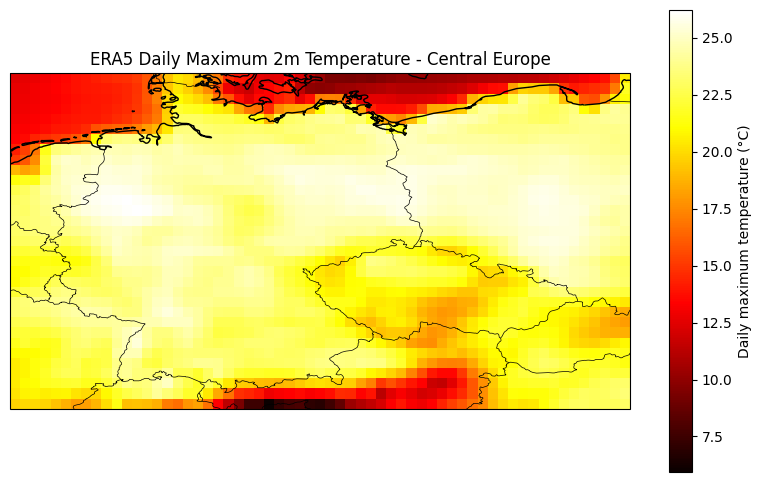

In [6]:
#  Plot the first day:
tmax = ds["t2m"].isel(valid_time=0) - 273.15  # Kelvin to Celsius

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

tmax.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="hot",
    cbar_kwargs={"label": "Daily maximum temperature (°C)"}
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("ERA5 Daily Maximum 2m Temperature - Central Europe")
plt.show()

## 2. Exposure Dataset: GHS-POP (Population)

To estimate climate exposure, we use the Global Human Settlement Population dataset (GHS-POP) developed by the European Commission's Joint Research Centre (JRC).

The dataset provides spatial population estimates derived from census data combined with satellite imagery and settlement maps.

Key features:
- Global population distribution
- Spatial resolution up to 1 km
 -Multiple years available
- Provided as GeoTIFF raster files

Dataset source:

>https://human-settlement.emergency.copernicus.eu/ghs_pop2023.php

When you click **Download the GHS-POP dataset**, you will see a setup with a few options to select:
- **Product**: GHS-POP, representing the spatial distribution of residential population (number of people per grid cell)
- **Epoch**: 2020, the reference year for the population estimate, providing a recent representation of global population distribution.
- **Resolution**: 1km, each grid cell represents approximately one square kilometer, offering a good balance between spatial detail and computational efficiency.
- **Coord. system**: Mollweide projection, an equal-area projection used to ensure consistent representation of population density across the globe. The GHS-POP dataset is distributed using the **Mollweide equal-area projection**. This projection **preserves area relationships**, which is particularly important for population datasets where each grid cell represents the number of people within a specific land area. Using an equal-area projection helps ensure that population density calculations remain consistent across the globe.

**Note**: ERA5 climate data is provided on a latitude–longitude grid using the WGS84 coordinate system. To combine population data with climate variables (such as temperature or precipitation), both datasets must use the same coordinate reference system and grid structure. Therefore, the GHS-POP dataset is reprojected from the Mollweide projection to WGS84, allowing it to be aligned with the ERA5 climate grid.


**Loading the GHS-POP raster**

The GHS-POP dataset is distributed as a **GeoTIFF raster**, so we use **rioxarray** to load it in Python.

rioxarray extends xarray with geospatial raster functionality, allowing us to:
- inspect the coordinate reference system (CRS)
- crop the raster to a study region
- reproject it to another CRS
- align it with climate datasets such as ERA5

Because the global population raster is very large, we also load it with chunks. This enables lazy loading with dask, so the full dataset is not read into memory at once.

In [2]:
# Let's check the dataset first 
import rioxarray as rxr

pop_path = "GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0/GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0.tif"

pop = rxr.open_rasterio(
    pop_path,
    masked=True,
    chunks={"x": 2048, "y": 2048}   # tweak if needed (1024 also fine)
).squeeze("band")

print(pop)
print("CRS:", pop.rio.crs)
print("Resolution:", pop.rio.resolution())

<xarray.DataArray (y: 18000, x: 36082)> Size: 5GB
dask.array<getitem, shape=(18000, 36082), dtype=float64, chunksize=(2048, 2048), chunktype=numpy.ndarray>
Coordinates:
    band         int64 8B 1
  * x            (x) float64 289kB -1.804e+07 -1.804e+07 ... 1.804e+07 1.804e+07
  * y            (y) float64 144kB 9e+06 8.998e+06 ... -8.998e+06 -9e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_MAXIMUM:        338726.57110608
    STATISTICS_MEAN:           56.785121486231
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         679.48856478339
    STATISTICS_VALID_PERCENT:  21.26
    scale_factor:              1.0
    add_offset:                0.0
CRS: ESRI:54009
Resolution: (1000.0, -1000.0)


### Clip the raster to Central Europe

Since the original raster is global and very large, we first crop it to the study area.

The GHS-POP raster is stored in the Mollweide projection, while our bounding box is easier to define in WGS84 latitude/longitude, so we first transform the bounding box coordinates.

In [7]:
import pyproj
import numpy as np

# Central Europe bounding box in WGS84
north, west, south, east = 55, 5, 47, 20

# Transform bounding box from WGS84 to the raster CRS (Mollweide)
transformer = pyproj.Transformer.from_crs("EPSG:4326", pop.rio.crs, always_xy=True)

xs, ys = transformer.transform(
    [west, east, west, east],
    [south, south, north, north]
)

minx, maxx = float(np.min(xs)), float(np.max(xs))
miny, maxy = float(np.min(ys)), float(np.max(ys))

print("Clipping bounds in Mollweide:")
print(minx, miny, maxx, maxy)

# Clip raster
pop_ce = pop.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)

print(pop_ce)

Clipping bounds in Mollweide:
353871.2689345557 5555784.3927511 1579099.9618520206 6386579.968095269
<xarray.DataArray (y: 832, x: 1227)> Size: 8MB
dask.array<getitem, shape=(832, 1227), dtype=float64, chunksize=(832, 1189), chunktype=numpy.ndarray>
Coordinates:
    band         int64 8B 1
  * x            (x) float64 10kB 3.535e+05 3.545e+05 ... 1.578e+06 1.58e+06
  * y            (y) float64 7kB 6.386e+06 6.386e+06 ... 5.556e+06 5.556e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_MAXIMUM:        338726.57110608
    STATISTICS_MEAN:           56.785121486231
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         679.48856478339
    STATISTICS_VALID_PERCENT:  21.26
    scale_factor:              1.0
    add_offset:                0.0


### Reproject to WGS84

ERA5 uses geographic coordinates (WGS84 / EPSG:4326), so we reproject the population raster to the same CRS.

In [8]:
pop_ce_wgs84 = pop_ce.rio.reproject("EPSG:4326")

print("Reprojected CRS:", pop_ce_wgs84.rio.crs)
print("Shape:", pop_ce_wgs84.shape)
print("Resolution:", pop_ce_wgs84.rio.resolution())

Reprojected CRS: EPSG:4326
Shape: (698, 1555)
Resolution: (0.01148379681204056, -0.01148379681204056)


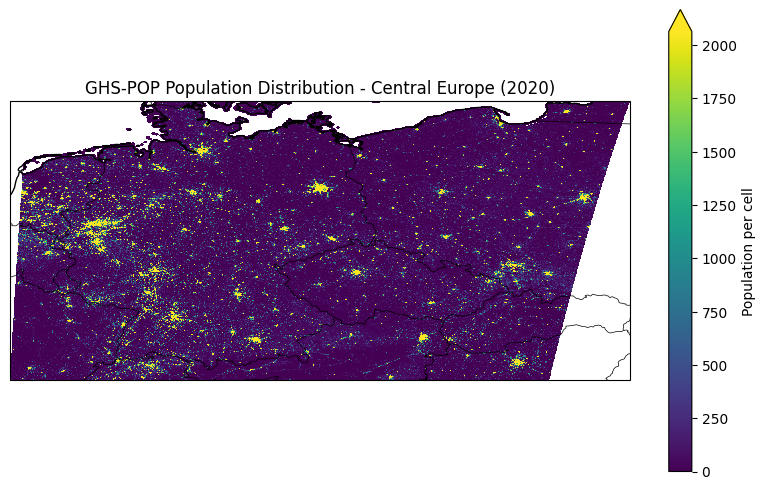

In [10]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.figure(figsize=(10,6))

ax = plt.axes(projection=ccrs.PlateCarree())

pop_ce_wgs84.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    robust=True,
    cbar_kwargs={"label": "Population per cell"}
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

ax.set_title("GHS-POP Population Distribution - Central Europe (2020)")

plt.show()

# 3. Vulnerability Dataset: World Bank Indicators

Climate vulnerability is strongly influenced by social and economic conditions.

In this exercise we use indicators from the **World Bank Open Data platform**, which provides global socio-economic statistics.

Website:
>https://data.worldbank.org

Example indicators:
| Indicator                     | Code              |
| ----------------------------- | ----------------- |
| Population ages 65+ (%)       | SP.POP.65UP.TO.ZS |
| GDP per capita                | NY.GDP.PCAP.CD    |
| Health expenditure per capita | SH.XPD.CHEX.PC.CD |

These correspond to:
- **Sensitivity** → elderly population share
- **Adaptive capacity** → economic resources
- **Response capacity** → health system investment

We could use the API(https://data360.worldbank.org/en/api) to download and load the data from those datasets.

The request URL looks like this:
> https://api.worldbank.org/v2/country/all/indicator/<INDICATOR_CODE>?format=json

Example:
> https://api.worldbank.org/v2/country/all/indicator/SP.POP.65UP.TO.ZS

The following is a robust code to download a dataset including the 3 Socioeconomic Vulnerability Indicators

In [11]:
# Step 1: Download and load the data from WorldBank API
import requests
import pandas as pd

def fetch_indicator(indicator_code, year="2024"):
    url = (
        f"https://api.worldbank.org/v2/country/all/indicator/"
        f"{indicator_code}?format=json&per_page=20000"
    )
    r = requests.get(url)
    js = r.json()

    # Handle API errors
    if not isinstance(js, list) or len(js) < 2:
        raise RuntimeError(f"World Bank API error for {indicator_code}: {js}")

    data = js[1]
    df = pd.json_normalize(data)

    # Keep chosen year + valid values
    df = df[df["date"] == str(year)]
    df = df[df["value"].notna()]

    # IMPORTANT: use ISO3 column
    df["countryiso3code"] = df["countryiso3code"].astype(str).str.strip().str.upper()

    # Keep only real ISO3 country codes (drops aggregates)
    df = df[df["countryiso3code"].str.fullmatch(r"[A-Z]{3}", na=False)]

    return df[["countryiso3code", "value"]].rename(columns={"value": indicator_code})

elderly = fetch_indicator("SP.POP.65UP.TO.ZS", year="2020")
gdp     = fetch_indicator("NY.GDP.PCAP.CD", year="2020")
health  = fetch_indicator("SH.XPD.CHEX.PC.CD", year="2020")

df = elderly.merge(gdp, on="countryiso3code", how="inner").merge(health, on="countryiso3code", how="inner")

df = df.rename(columns={
    "countryiso3code": "iso3",
    "SP.POP.65UP.TO.ZS": "elderly_pct",
    "NY.GDP.PCAP.CD": "gdp_per_capita",
    "SH.XPD.CHEX.PC.CD": "health_exp"
})

print(df.shape)
df.head()

(234, 4)


,iso3,elderly_pct,gdp_per_capita,health_exp
0,AFE,3.192169,1351.591669,81.446140
1,AFW,2.916504,2030.861659,64.624190
2,ARB,4.270911,5739.412836,327.069626
3,CSS,8.919143,11957.223223,796.157980
4,CEB,19.154477,16581.352612,1187.604626


## Exercise 1 — Climate Risk Framework

Students apply:

> Risk = Hazard × Exposure × Vulnerability

**Tasks**:
1. Choose a climate hazard dataset (ERA5 temperature or precipitation).
2. Choose an exposure dataset (GHS-POP population density).
3. Choose one vulnerability indicator (World Bank).

Then answer:
- Which regions show high hazard and high population exposure?
- Which regions might have higher vulnerability due to socio-economic factors?
- How might climate impacts differ between developed and developing regions?

Students present their findings.

## Optional Exercise — Community Vulnerability Assessment

Students pick a real city.

Example cities:
- Jakarta
- Manila
- Bangkok

Questions:
- What climate hazards affect the city?
- What population factors increase exposure?
- What socio-economic factors affect adaptive capacity?

This aligns nicely with the Southeast Asia flood case study.
